# Recovering PDF/CDF from Characteristic Functions

If the characteristic function is known, we can recover the PDF and CDF without needing the density in closed form. The characteristic function of a random variable $X$:

$$ \varphi_X(t) = \mathbb{E}[e^{itX}] = \int_{-\infty}^{+\infty} e^{itx}f_X(x) \, \mathrm{d}x $$

is the Fourier transform of the density. Inverting it gives us back the PDF:

$$ f_X(x) = \frac{1}{2\pi}\int_{-\infty}^{+\infty} e^{-itx}\varphi_X(t) \, \mathrm{d}t $$

This is useful for option pricing when we have an analytical CF (Black-Scholes, Heston, Variance-Gamma, etc.) but no closed-form density. We can price options by computing:

$$ v(x, t_0) = e^{-r\Delta t} \int_\mathbb{R} v(y, T) f(y \mid x) \, \mathrm{d}y $$

Three methods for this inversion: **COS**, **Carr-Madan**, and **CONV**. Each has different convergence properties. COS converges exponentially (N~64 for machine precision on smooth densities), Carr-Madan and CONV algebraically (N~256+).

In [ ]:
# Import all functions from utils to avoid code duplication
import sys
sys.path.insert(0, '..')
from utils import *

## COS Method

The COS method {cite:t}`FangOosterlee2008` expands the density as a Fourier cosine series on $[a,b]$:

$$f(x) \approx \sum_{k=0}^{N-1} A_k \cos\left(k \pi \frac{x-a}{b-a}\right)$$

The coefficients $A_k$ can be computed directly from the characteristic function:

$$A_k = \frac{2}{b-a} \text{Re}\left\{ \varphi\left( \frac{k\pi}{b-a} \right) \exp\left(-i \frac{k\pi a}{b-a}\right) \right\}$$

No numerical integration needed — just evaluate the CF at specific frequencies. For smooth densities, convergence is exponential: $O(\rho^N)$ with $\rho < 1$. With N=64 you often hit machine precision.

The CDF follows by integrating the series:

$$F(x) = \frac{A_0}{2}(x-a) + \sum_{k=1}^{N-1} \frac{A_k}{\omega_k} \sin(\omega_k(x-a))$$

where $\omega_k = k\pi/(b-a)$.

Domain $[a,b]$ should capture most of the probability mass — typically $[\mu - L\sigma, \mu + L\sigma]$ with $L \approx 10$.

Standard normal density recovery — sweep N from 4 to 64 on $[-10, 10]$ and measure max absolute error.

In [2]:
# Recovery CDF
def cos_cdf(a, b, omega, chf, x):
    # F_k coefficients
    F_k = 2.0 / (b - a) * np.real(chf * np.exp(-1j * omega * a))
    cdf = np.squeeze(F_k[0] / 2.0 * (x - a)) + np.matmul(F_k[1:] / omega[1:], np.sin(np.outer(omega[1:], x - a)))
    
    return cdf

# Recover PDF
def cos_pdf(a, b, omega, chf, x): 
    # F_k coefficients
    F_k = 2.0 / (b - a) * np.real(chf * np.exp(-1j * omega * a))
    # Separate first term and remaining terms like in cos_cdf
    pdf = F_k[0] / 2.0 + np.matmul(F_k[1:], np.cos(np.outer(omega[1:], x - a)))
    
    return pdf

def cos_pdf2(a, b, N, chf, x): # chf(omega)
    #i = np.complex(0.0, 1.0)  # assigning i=sqrt(-1)
    k = np.linspace(0, N-1, N)
    #u = np.zeros([1,N]) # Num of arguments for ch.f.
    u = k * np.pi / (b-a) # scale; frequencies -- u = omega 
    # F_k coefficients
    F_k = 2.0 / (b - a) * np.real(chf(u) * np.exp(-1j * u * a))
    F_k[0] = F_k[0] * 0.5  # first term
    # Final calculation
    pdf = np.matmul(F_k, np.cos(np.outer(u, x - a)))
    
    return pdf


Convergence table:


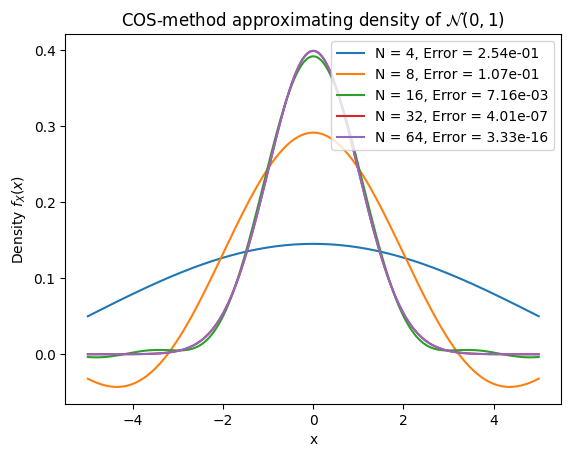

    N         Error  CPU time (msec.)  Diff. in CPU (msec.)
0   4  2.536344e-01          0.065970                   NaN
1   8  1.074376e-01          0.016093             -0.049877
2  16  7.158203e-03          0.021815              0.005722
3  32  4.008963e-07          0.035739              0.013924
4  64  3.330669e-16          0.068688              0.032949

Testing CDF recovery:


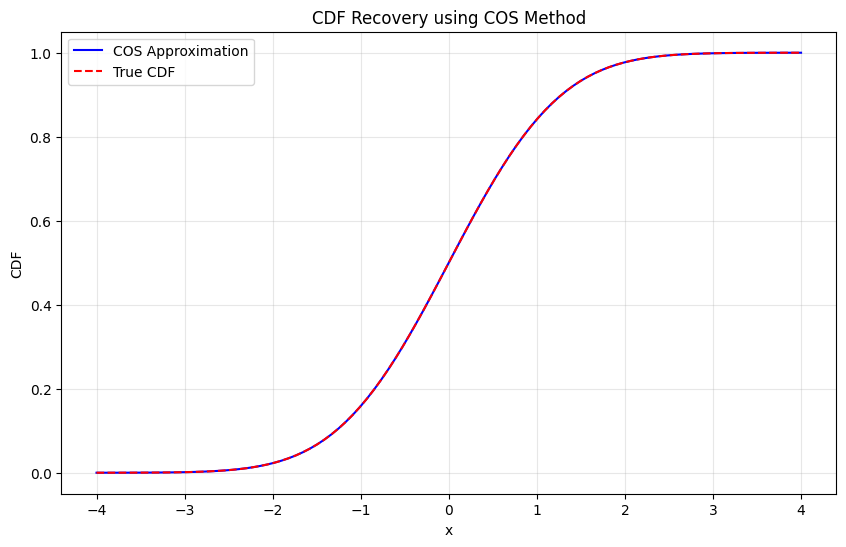

Maximum CDF error: 5.55e-16


In [3]:
# Test
def generate_cos_convergence_analysis():
    """ Make a plot & table of error convergence of COS method for approximating PDF of standard normal 
    """
    # Define characteristic function of standard normal
    def chf_normal(omega):
        return np.exp(-0.5 * omega**2)
    
    # Setup test parameters
    a, b = -10, 10                   # Domain boundaries
    x = np.linspace(-5, 5, 200)      # Points to evaluate
    exact_pdf = norm.pdf(x)          # Exact pdf to match
    N_values = [4, 8, 16, 32, 64]    # Number of terms to test
    
    # Initialise vectors
    errors = []
    cpu_times = []
    diff_cpu_times = []
        
    prev_time = 0
    
    # Test each value of N
    for N in N_values:
        # Compute frequencies (omega) for this N
        k = np.linspace(0, N-1, N)
        omega = k * np.pi / (b - a)
        
        # Pre-compute characteristic function values
        chf_values = chf_normal(omega)
        
        # Measure CPU time correctly
        times = []
        for _ in range(10):  # Run more times for more stable timing
            start = time.time()
            # Use the new cos_pdf signature with pre-computed values
            cos_pdf_values = cos_pdf(a, b, omega, chf_values, x)
            end = time.time()
            times.append((end - start) * 1000)  # Convert to milliseconds
        
        cpu_time = np.mean(times)
        
        # Calculate maximum error
        error = np.max(np.abs(cos_pdf_values - exact_pdf))
        
        # Calculate difference in CPU time
        diff_time = cpu_time - prev_time if N != 4 else 0
        
        # Store results
        errors.append(error)
        cpu_times.append(cpu_time)
        diff_cpu_times.append(diff_time if N != 4 else None)  # Set first row = None
        
        prev_time = cpu_time
    
        # Plot of the approximations
        plt.plot(x, cos_pdf_values, label=f'N = {N}, Error = {error:.2e}')
    
    plt.title(r"COS-method approximating density of $\mathcal{N}(0,1)$")
    plt.xlabel("x")
    plt.ylabel("Density $f_X(x)$")
    plt.legend()  
    plt.show()
    
    # Create a pandas DataFrame
    results_df = pd.DataFrame({
        'N': N_values,
        'Error': errors,
        'CPU time (msec.)': cpu_times,
        'Diff. in CPU (msec.)': diff_cpu_times
    })
    return results_df

# Test COS CDF recovery
def test_cos_cdf():
    """ Test CDF recovery for standard normal """
    def chf_normal(u): 
        return np.exp(-0.5 * u**2)
    
    x_vals = np.linspace(-4, 4, 100)
    
    # Recover CDF
    a, b, = -8.0, 8.0
    N = 2**12
    k_values = np.arange(N)
    omega = k_values * np.pi / (b - a)
    chf_values = chf_normal(omega)
    
    cdf_approx = cos_cdf(a, b, omega, chf_values, x_vals)
    
    # True CDF
    cdf_true = norm.cdf(x_vals)
    
    # Plot comparison
    plt.figure(figsize=(10, 6))
    plt.plot(x_vals, cdf_approx, 'b-', label='COS Approximation')
    plt.plot(x_vals, cdf_true, 'r--', label='True CDF')
    plt.title("CDF Recovery using COS Method")
    plt.xlabel("x")
    plt.ylabel("CDF")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Report error
    max_error = np.max(np.abs(cdf_approx - cdf_true))
    print(f"Maximum CDF error: {max_error:.2e}")

# Run tests
if __name__ == "__main__":    
    print("\nConvergence table:")
    print(generate_cos_convergence_analysis()) # includes the plot
    
    print("\nTesting CDF recovery:")
    test_cos_cdf()

## Carr-Madan Method

Uses Gil-Pelaez inversion. The CDF:

$$F(x) = \frac{1}{2} - \frac{1}{\pi} \int_0^{\infty} \frac{\text{Im}[\varphi(u) e^{-iux}]}{u} du$$

The PDF via inverse Fourier transform:

$$f(x) = \frac{1}{2\pi} \int_{-\infty}^{\infty} \varphi(u) e^{-iux} du$$

For numerical stability (especially heavy tails), add a damping factor $\alpha > 0$:

$$f_{\alpha}(x) = \frac{1}{2\pi} \int_{-\infty}^{\infty} \varphi(u - i\alpha) e^{-iux} du$$

Then recover: $f(x) = e^{\alpha x} f_{\alpha}(x)$.

Truncate to $[-u_{\max}, u_{\max}]$ and use FFT for $O(N \log N)$ complexity. Convergence is algebraic: $O(N^{-p})$ where $p$ depends on how fast $|\varphi(u)|$ decays.

Damping $\alpha \in [0.5, 1.5]$ works for most cases. Sensitive to parameter choice — need to tune $\alpha$ and $u_{\max}$.

Same test as COS. Carr-Madan needs more grid points since convergence is algebraic.

In [4]:
N_values = [16, 32, 64, 128, 256, 512]

In [5]:
# Recover CDF
def carr_madan_cdf(chf, x_grid, u_max=200, N=2**12):
    """
    Recover CDF from characteristic function using Gil-Pelaez inversion formula.
    Parameters:
    - chf: function, characteristic function phi(u)
    - x_grid: np.array, evaluation points for CDF
    - u_max: upper frequency limit (increased for better tail accuracy)
    - N: number of frequency discretization points (increased for better resolution)
    Returns:
    - cdf: np.array, CDF values at x_grid
    """
    # Starting from close to 0
    u_min = 1e-10  # Much smaller starting point to capture low-frequency behavior
    u = np.linspace(u_min, u_max, N)
    
    # Compute integrand for each x (unchanged)
    integrand = np.imag(np.exp(-1j * np.outer(x_grid, u)) * chf(u)) / u  # shape: (len(x), N)
    
    # Integrate using trapezoidal rule along frequency axis (unchanged)
    integral = trapezoid(integrand, u, axis=1)
    
    # Apply Gil-Pelaez inversion formula
    cdf = 0.5 - (1 / np.pi) * integral
    
    return np.clip(np.squeeze(cdf), 0.0, 1.0)  # Clamp in [0,1]

# Recover PDF
def carr_madan_pdf(chf, x_grid, u_max=200, N=2**12):
    """Recover PDF using Carr-Madan method (Inverse Fourier Transform) """
    du = 2 * u_max / N
    u = np.linspace(-u_max, u_max - du, N)
    
    # Compute integrand of inverse Fourier transform
    integrand = np.exp(-1j * np.outer(x_grid, u)) * chf(u)
    
    # Numerical integration using trapezoidal rule
    integral = trapezoid(integrand, u, axis=1)
    
    pdf = np.squeeze(np.real(integral) / (2 * np.pi))
    return pdf


In [6]:
def carr_madan_pdf(chf, x_range=(-5, 5), N=2**12, alpha=0.0):
    x_min, x_max = x_range
    L = x_max - x_min
    dx = L / N
    du = 2*np.pi / L

    # Build symmetric frequency grid compatible with FFT ordering
    # Use np.fft.fftfreq to avoid off-by-one mishaps, then scale & shift.
    k = np.fft.fftfreq(N, d=dx)  # cycles per unit x
    u = 2*np.pi * k               # angular frequencies
    # Put into "FFT input order": DC at index 0, positives up, then negatives
    # u returned by fftfreq is already in that order; for explicit symmetry handling:
    # (no shift needed for input to np.fft.fft)
    
    # Real-space grid in the desired interval
    x = x_min + np.arange(N) * dx

    # Damping (optional): evaluate at u - i*alpha
    if alpha and alpha != 0.0:
        phi = chf(u - 1j*alpha)
    else:
        phi = chf(u)

    # Phase to anchor the transform at x_min
    integrand = phi * np.exp(-1j * u * x_min)

    # FFT of the frequency samples
    F = np.fft.fft(integrand)

    # Scale and undamp
    pdf = (du / (2*np.pi)) * np.real(F)
    if alpha and alpha != 0.0:
        pdf *= np.exp(-alpha * x)

    return x, pdf



Convergence plot and table:


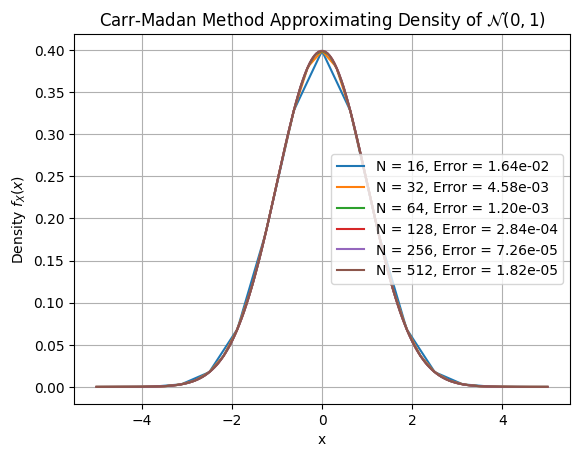

     N     Error  CPU time (msec.)  Diff. in CPU (msec.)
0   16  0.016351          0.193214                   NaN
1   32  0.004577          0.061750             -0.131464
2   64  0.001203          0.135040              0.073290
3  128  0.000284          0.028133             -0.106907
4  256  0.000073          0.026608             -0.001526
5  512  0.000018          0.090647              0.064039

Testing CDF recovery:


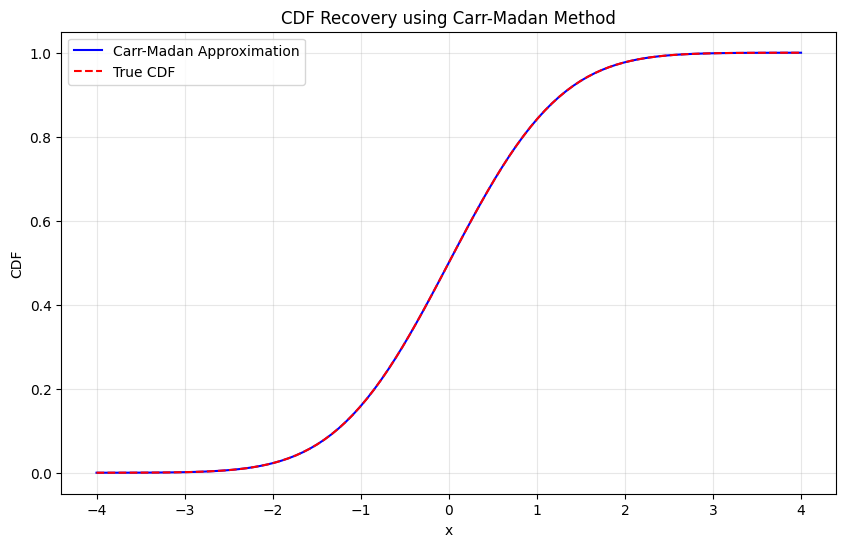

Maximum CDF error: 1.27e-10


In [7]:
# Test Carr-Madan
def generate_carr_madan_convergence_analysis():
    """ Make a plot & table of error convergence for Carr-Madan method approximating PDF of standard normal """
    def chf_normal(u):
        return np.exp(-0.5 * u**2)
    
    x = np.linspace(-5, 5, 200)
    exact_pdf = norm.pdf(x)
    #N_values = [16, 32, 64, 128, 256, 512]  # FFT sizes
    
    errors = []
    cpu_times = []
    diff_cpu_times = []
    
    prev_time = 0
    
    for N in N_values:
        times = []
        for _ in range(5):  # Run a few times for stability
            start = time.time()
            x_cm, pdf_vals_cm = carr_madan_pdf(chf_normal, x_range=(-5, 5), N=N)
            pdf_vals = np.interp(x, x_cm, pdf_vals_cm)
            end = time.time()
            times.append((end - start) * 1000)  # ms
        
        cpu_time = np.mean(times)
        error = np.max(np.abs(pdf_vals - exact_pdf))
        diff_time = cpu_time - prev_time if N != N_values[0] else 0
        
        errors.append(error)
        cpu_times.append(cpu_time)
        diff_cpu_times.append(diff_time if N != N_values[0] else None)
        
        prev_time = cpu_time
        
        # Plot
        plt.plot(x, pdf_vals, label=f'N = {N}, Error = {error:.2e}')
    
    plt.title(r"Carr-Madan Method Approximating Density of $\mathcal{N}(0,1)$")
    plt.xlabel("x")
    plt.ylabel("Density $f_X(x)$")
    plt.legend()
    plt.grid(True)
    plt.show()
    
    results_df = pd.DataFrame({
        'N': N_values,
        'Error': errors,
        'CPU time (msec.)': cpu_times,
        'Diff. in CPU (msec.)': diff_cpu_times
    })
    
    return results_df

# Test Carr-Madan CDF recovery
def test_carr_madan_cdf():
    """ Test CDF recovery for standard normal """
    def chf_normal(u): 
        return np.exp(-0.5 * u**2)
    
    x_vals = np.linspace(-4, 4, 100)
    
    # Recover CDF
    cdf_approx = carr_madan_cdf(chf_normal, x_vals, N=2**12)
    
    # True CDF
    cdf_true = norm.cdf(x_vals)
    
    # Plot comparison
    plt.figure(figsize=(10, 6))
    plt.plot(x_vals, cdf_approx, 'b-', label='Carr-Madan Approximation')
    plt.plot(x_vals, cdf_true, 'r--', label='True CDF')
    plt.title("CDF Recovery using Carr-Madan Method")
    plt.xlabel("x")
    plt.ylabel("CDF")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Report error
    max_error = np.max(np.abs(cdf_approx - cdf_true))
    print(f"Maximum CDF error: {max_error:.2e}")
    
# Run tests
if __name__ == "__main__":    
    print("\nConvergence plot and table:")
    print(generate_carr_madan_convergence_analysis()) # includes the plot
    
    print("\nTesting CDF recovery:")
    test_carr_madan_cdf()

## CONV Method

Discretizes the inverse Fourier transform and uses FFT. Same underlying formula as Carr-Madan:

$$f(x) = \frac{1}{2\pi} \int_{-\infty}^{\infty} \varphi(u) e^{-iux} du$$

Grid setup:
- Spatial: $x_k = x_{\min} + k \cdot \Delta x$
- Frequency: $u_j = j \cdot \Delta u$ where $\Delta u = 2\pi / L$ and $L = x_{\max} - x_{\min}$

The discrete approximation:

$$f(x_k) \approx \frac{\Delta u}{2\pi} \sum_{j=0}^{N-1} \varphi(u_j) e^{-iu_j x_k}$$

This is just an inverse DFT — use `np.fft.fft` with proper scaling.

Add damping $\alpha$ for stability with heavy tails, same as Carr-Madan. The phase correction $e^{-iu_j x_{\min}}$ shifts the output to the desired spatial domain.

Complexity: $O(N \log N)$. More robust than Carr-Madan for unknown distributions. Convergence is spectral for smooth CFs, algebraic otherwise.

Same test. CONV uses FFT with phase correction — similar to Carr-Madan but different grid handling.

Testing PDF recovery:


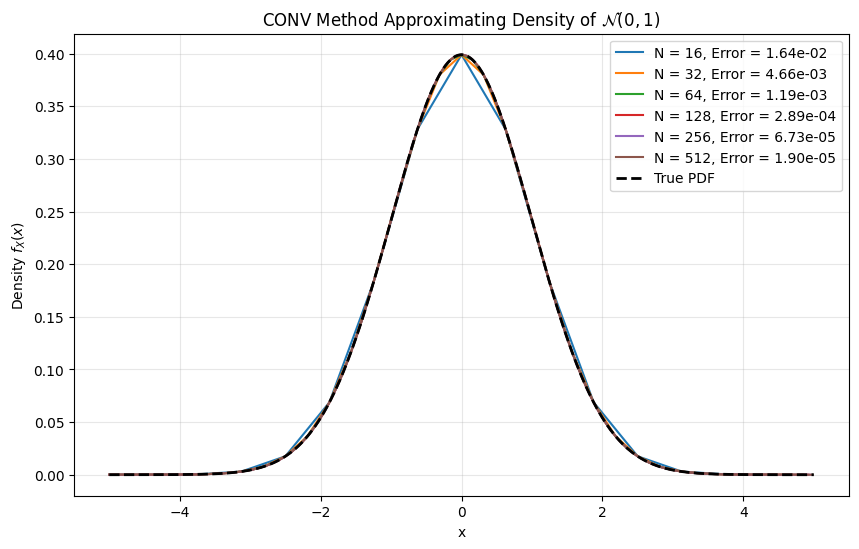


Convergence table:
     N     Error  CPU time (msec.)  Diff. in CPU (msec.)
0   16  0.016413          0.085187                   NaN
1   32  0.004663          0.033998             -0.051188
2   64  0.001192          0.033522             -0.000477
3  128  0.000289          0.035524              0.002003
4  256  0.000067          0.041294              0.005770
5  512  0.000019          0.103831              0.062537

Testing CDF recovery:


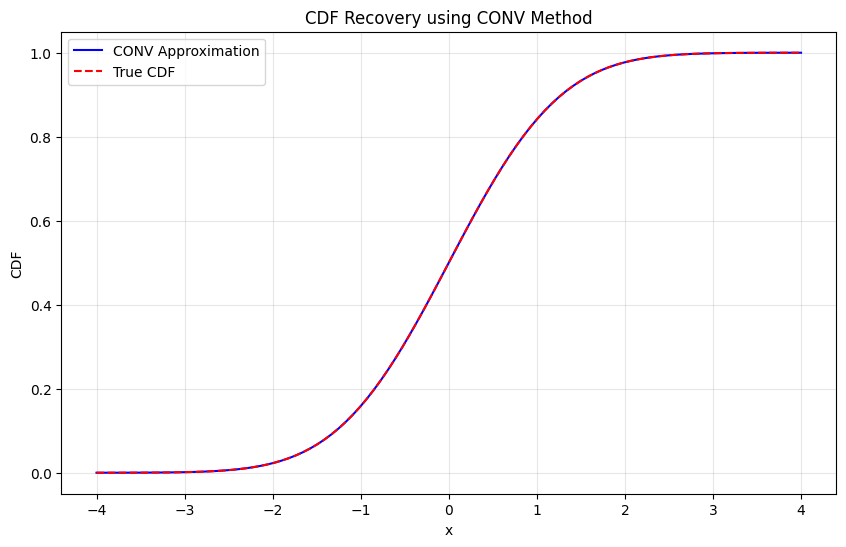

Maximum CDF error: 7.56e-07


In [8]:
def conv_pdf(chf, x_range=(-5, 5), alpha=0.0, N=2**12):
    """
    CONV method for PDF recovery using FFT
    """
    
    # Step 1: Set up the grids
    x_min, x_max = x_range
    L = x_max - x_min  # Total length of spatial domain
    
    # Spatial and frequency grid spacings
    dx = L / N
    du = 2 * np.pi / L
    
    # Step 2: Create the frequency grid
    # For FFT, we need frequencies from -u_max to u_max where u_max = pi/dx
    # But FFT expects a specific ordering
    u_max = np.pi / dx  # Nyquist frequency
    
    # Create frequency array in "standard" order from -u_max to u_max
    if N % 2 == 0:
        # For even N: [-N/2, -N/2+1, ..., -1, 0, 1, ..., N/2-1] x du
        k = np.concatenate([np.arange(-N//2, 0), np.arange(0, N//2)])
    else:
        # For odd N: [-(N-1)/2, ..., -1, 0, 1, ..., (N-1)/2] x du
        k = np.arange(-(N-1)//2, (N+1)//2)
    
    u = k * du
    
    # Step 3: Create the spatial grid
    # Important: This grid corresponds to the FFT output ordering
    x = x_min + np.arange(N) * dx
    
    # Step 4: Evaluate the damped characteristic function
    # phi(u - ia) provides exponential damping for numerical stability
    phi_damped = chf(u - 1j * alpha)
    
    # Step 5: Prepare the integrand for FFT
    # We need to include a phase factor to account for the shift to x_min
    # The continuous transform of phi(u)e^{-iu x_min} gives f(x + x_min)
    integrand = phi_damped * np.exp(-1j * u * x_min)
    
    # Step 6: Apply FFT with correct ordering
    # FFT expects input in order [0, 1, ..., N/2-1, -N/2, ..., -1]
    # So we need to reorder our frequency-domain data
    integrand_fft_order = np.fft.ifftshift(integrand)
    
    # Step 7: Compute the FFT
    # This approximates the integral \int{ phi(u-ia) e^{-iu(x-x_min)} du }
    fft_result = np.fft.fft(integrand_fft_order)
    
    # Step 8: Extract and normalize the PDF
    # The factor du converts the sum to an integral
    # The factor 1/(2pi) comes from the inverse Fourier transform
    # The factor e^{-ax} removes the damping we introduced
    pdf = np.real(fft_result) * np.exp(-alpha * x) * du / (2 * np.pi)
    
    # Step 9: Ensure non-negativity (small numerical errors can cause negative values)
    pdf = np.maximum(pdf, 0)
    
    # Check: Normalize to ensure integral equals 1
    integral = trapezoid(pdf, x)
    if integral > 0:
        pdf = pdf / integral
    
    return x, pdf

def conv_cdf(chf, x_vals, x_range=None, alpha=0.0, N=2**13):
    """Recover CDF directly from characteristic function by integrating the recovered PDF."""
    
    # Step 1: Determine the domain for PDF recovery
    if x_range is None:
        # Automatically choose a domain that covers x_vals with some padding
        # This ensures we capture the full probability mass
        x_min_req = np.min(x_vals)
        x_max_req = np.max(x_vals)
        padding = (x_max_req - x_min_req) * 0.5  # 50% padding on each side
        x_range = (x_min_req - padding, x_max_req + padding)
    
    # Step 2: Recover the PDF using our existing function
    x_grid, pdf_grid = conv_pdf(chf=chf, x_range=x_range, alpha=alpha, N=N)
    
    # Step 3: Compute CDF on the native grid by cumulative integration
    # Using the trapezoidal rule for integration
    dx = x_grid[1] - x_grid[0]  # Grid spacing (uniform)
    cdf_grid = np.zeros_like(pdf_grid)
    
    # Integrate from left to right: CDF[i] = \int_{-\infty}^{x[i]} PDF(t) dt
    cdf_grid[0] = 0.0  # CDF starts at 0 at the leftmost point
    for i in range(1, len(cdf_grid)):
        # Add the area of the trapezoid between points i-1 and i
        cdf_grid[i] = cdf_grid[i-1] + 0.5 * (pdf_grid[i-1] + pdf_grid[i]) * dx
    
    # Alternative vectorized approach (more efficient):
    # cdf_grid = np.concatenate([[0], np.cumsum(0.5 * (pdf_grid[:-1] + pdf_grid[1:]) * dx)])
    
    # Step 4: Interpolate CDF to the requested x_vals
    cdf_vals = np.interp(x_vals, x_grid, cdf_grid)
    
    # Step 5: Ensure CDF properties are satisfied
    # CDF should be between 0 and 1, and monotonically increasing
    cdf_vals = np.clip(cdf_vals, 0.0, 1.0)
    
    return cdf_vals

def conv_cdf_GP(chf, x_vals, u_max=100, N=2**13):
    r""" Recover CDF using Gil-Pelaez inversion formula
        CDF(x) = 1/2 - (1/pi) \int_0^\infty Im[e^(-iux)phi(u)]/u du """
    # Use positive u only (integrand is odd in u)
    du = u_max / N
    u = np.linspace(du, u_max, N)  # avoid u=0 singularity
    
    # Vectorized computation for all x values
    integrand = np.imag(np.exp(-1j * np.outer(x_vals, u)) * chf(u)) / u
    
    # Integrate over u for each x
    integral = trapezoid(integrand, u, axis=1)
    
    # Apply inversion formula
    cdf = 0.5 - (1 / np.pi) * integral
    
    return np.clip(cdf, 0.0, 1.0)


# Test functions
def plot_conv_pdf_convergence():
    """ Test PDF recovery with standard normal distribution """
    def chf_normal(u): 
        return np.exp(-0.5 * u**2)
    
    x_true = np.linspace(-5, 5, 500)
    exact_pdf = norm.pdf(x_true)
    
    plt.figure(figsize=(10, 6))
    
    # Store errors for the table
    results = []
    
    for N in N_values:
        # Use fixed domain and moderate damping
        x, pdf = conv_pdf(chf=chf_normal, x_range=(-5, 5), alpha=0.0, N=N)
        
        # Interpolate to common grid for comparison
        interp_pdf = np.interp(x_true, x, pdf)
        error = np.max(np.abs(interp_pdf - exact_pdf))
        
        plt.plot(x, pdf, label=f'N = {N}, Error = {error:.2e}')
        results.append((N, error))
    
    plt.plot(x_true, exact_pdf, 'k--', linewidth=2, label='True PDF')
    plt.title(r"CONV Method Approximating Density of $\mathcal{N}(0,1)$")
    plt.xlabel("x")
    plt.ylabel("Density $f_X(x)$")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return results


def generate_conv_convergence_table():
    """ Generate convergence table with timings """
    def chf_normal(u): 
        return np.exp(-0.5 * u**2)
    
    # Create a common reference grid for fair comparison
    x_true = np.linspace(-5, 5, 500)
    true_pdf = norm.pdf(x_true)
    
    errors = []
    cpu_times = []
    diff_cpu_times = []
    prev_time = 0
    
    for N in N_values:
        # Time multiple runs for accuracy
        times = []
        for _ in range(10):
            start = time.time()
            x, pdf = conv_pdf(chf=chf_normal, x_range=(-5, 5), alpha=0.0, N=N)
            end = time.time()
            times.append((end - start) * 1000)
        
        avg_time = np.mean(times)
        
        # Interpolate to common grid before computing error
        interp_pdf = np.interp(x_true, x, pdf)
        error = np.max(np.abs(interp_pdf - true_pdf))
        
        # Time difference
        delta_time = avg_time - prev_time if N != N_values[0] else None
        
        errors.append(error)
        cpu_times.append(avg_time)
        diff_cpu_times.append(delta_time)
        prev_time = avg_time
    
    table = pd.DataFrame({
        'N': N_values,
        'Error': errors,
        'CPU time (msec.)': cpu_times,
        'Diff. in CPU (msec.)': diff_cpu_times
    })
    
    return table

# Test CDF recovery
def test_conv_cdf():
    """ Test CDF recovery for standard normal """
    def chf_normal(u): 
        return np.exp(-0.5 * u**2)
    
    x_vals = np.linspace(-4, 4, 100)
    
    # Recover CDF
    cdf_approx = conv_cdf(chf_normal, x_vals, alpha=0.5, N=2**12)
    
    # True CDF
    cdf_true = norm.cdf(x_vals)
    
    # Plot comparison
    plt.figure(figsize=(10, 6))
    plt.plot(x_vals, cdf_approx, 'b-', label='CONV Approximation')
    plt.plot(x_vals, cdf_true, 'r--', label='True CDF')
    plt.title("CDF Recovery using CONV Method")
    plt.xlabel("x")
    plt.ylabel("CDF")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Report error
    max_error = np.max(np.abs(cdf_approx - cdf_true))
    print(f"Maximum CDF error: {max_error:.2e}")


# Run tests
if __name__ == "__main__":
    print("Testing PDF recovery:")
    plot_conv_pdf_convergence()
    
    print("\nConvergence table:")
    print(generate_conv_convergence_table())
    
    print("\nTesting CDF recovery:")
    test_conv_cdf()

In [9]:
def summary_convergence_table():
    """ Generate convergence comparison table for all three methods """
    def chf_normal(u): 
        return np.exp(-0.5 * u**2)
    
    # Create a common reference grid for fair comparison
    x_true = np.linspace(-5, 5, 500)
    true_pdf = norm.pdf(x_true)
    
    # Setup test parameters
    a, b = -10, 10                   # Domain boundaries for COS
    N_values = [16, 32, 64, 128, 256]    # Number of terms to test
    
    results = []
    
    for N in N_values:
        # --- COS Method ---
        k = np.linspace(0, N-1, N)
        omega = k * np.pi / (b - a)
        chf_values = chf_normal(omega)
        
        times_cos = []
        for _ in range(10):
            start = time.time()
            pdf_cos = cos_pdf(a, b, omega, chf_values, x_true)
            end = time.time()
            times_cos.append((end - start) * 1000)
        
        error_cos = np.max(np.abs(pdf_cos - true_pdf))
        cpu_cos = np.mean(times_cos)
        
        # --- Carr-Madan Method ---
        times_cm = []
        for _ in range(10):
            start = time.time()
            x_cm, pdf_cm = carr_madan_pdf(chf=chf_normal, x_range=(-5, 5), N=N)
            interp_pdf_cm = np.interp(x_true, x_cm, pdf_cm)
            end = time.time()
            times_cm.append((end - start) * 1000)
        
        error_cm = np.max(np.abs(interp_pdf_cm - true_pdf))
        cpu_cm = np.mean(times_cm)
        
        # --- CONV Method ---
        times_conv = []
        for _ in range(10):
            start = time.time()
            x_conv, pdf_conv = conv_pdf(chf=chf_normal, x_range=(-5, 5), alpha=0.0, N=N)
            interp_pdf_conv = np.interp(x_true, x_conv, pdf_conv)
            end = time.time()
            times_conv.append((end - start) * 1000)
        
        error_conv = np.max(np.abs(interp_pdf_conv - true_pdf))
        cpu_conv = np.mean(times_conv)
        
        # Store results
        results.append({
            'N': N,
            'Method': 'COS',
            'Error': error_cos,
            'CPU time (ms)': cpu_cos
        })
        results.append({
            'N': N,
            'Method': 'Carr-Madan',
            'Error': error_cm,
            'CPU time (ms)': cpu_cm
        })
        results.append({
            'N': N,
            'Method': 'CONV',
            'Error': error_conv,
            'CPU time (ms)': cpu_conv
        })
    
    # Create DataFrame and pivot for better display
    df = pd.DataFrame(results)
    
    # Create separate tables for Error and CPU time
    error_table = df.pivot(index='N', columns='Method', values='Error')
    cpu_table = df.pivot(index='N', columns='Method', values='CPU time (ms)')
    
    print("=" * 70)
    print("CONVERGENCE COMPARISON: Maximum Absolute Error")
    print("=" * 70)
    print(error_table.to_string())
    print("\n")
    print("=" * 70)
    print("PERFORMANCE COMPARISON: CPU Time (milliseconds)")
    print("=" * 70)
    print(cpu_table.to_string())
    print("\n")
    
    return df

# Call the function to display results
summary_convergence_table()


CONVERGENCE COMPARISON: Maximum Absolute Error
Method      CONV           COS  Carr-Madan
N                                         
16      0.016413  7.172372e-03    0.016416
32      0.004663  4.032330e-07    0.004663
64      0.001192  3.608225e-16    0.001193
128     0.000289  3.608225e-16    0.000289
256     0.000067  3.608225e-16    0.000067


PERFORMANCE COMPARISON: CPU Time (milliseconds)
Method      CONV       COS  Carr-Madan
N                                     
16      0.068569  0.102067    0.018382
32      0.038600  0.088763    0.017381
64      0.042224  0.160789    0.019789
128     0.061560  0.383806    0.023413
256     0.052810  0.770259    0.027919




,N,Method,Error,CPU time (ms)
0,16,COS,7.172372e-03,0.102067
1,16,Carr-Madan,1.641613e-02,0.018382
2,16,CONV,1.641260e-02,0.068569
3,32,COS,4.032330e-07,0.088763
4,32,Carr-Madan,4.663137e-03,0.017381
5,32,CONV,4.662527e-03,0.038600
6,64,COS,3.608225e-16,0.160789
7,64,Carr-Madan,1.192675e-03,0.019789
8,64,CONV,1.192463e-03,0.042224
9,128,COS,3.608225e-16,0.383806


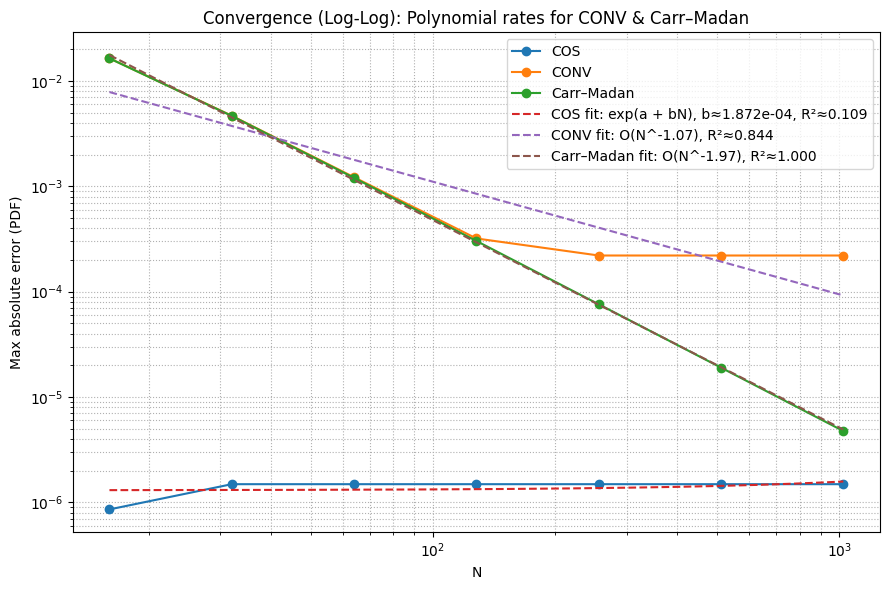


=== Empirical Convergence Summary ===
COS: last N=1024, error=1.487e-06, R²≈0.109
CONV: last N=1024, error=2.206e-04, R²≈0.844
Carr–Madan: last N=1024, error=4.753e-06, R²≈1.000


In [10]:
# --- Target CF: standard normal ---
def chf_normal(u):
    return np.exp(-0.5 * u**2)

# --- Common evaluation setup ---
x_range = (-5.0, 5.0)
grid_points = 2001
x_true = np.linspace(x_range[0], x_range[1], grid_points)
true_pdf = norm.pdf(x_true)

# --- Method runners that return (x, pdf) ---
def run_cos(N):
    a, b = x_range
    x = np.linspace(a, b, grid_points)
    pdf = cos_pdf2(a=a, b=b, N=N, chf=chf_normal, x=x)  # returns pdf-on-x
    return x, pdf

def run_conv(N, alpha=0.5):
    return conv_pdf(chf=chf_normal, x_range=x_range, alpha=alpha, N=N)

def run_cm(N):
    """Carr–Madan robust wrapper handling either x_range or x_grid signature."""
    # Preferred path: function returns (x, pdf) when given x_range
    try:
        x, pdf = carr_madan_pdf(chf=chf_normal, x_range=x_range, N=N)
        return x, pdf
    except TypeError:
        # Fallback: function expects an x grid and returns pdf on it
        x = np.linspace(x_range[0], x_range[1], grid_points)
        pdf = carr_madan_pdf(chf=chf_normal, x_grid=x, N=N)  # or carr_madan_pdf(chf, x, N=N)
        return x, pdf

methods = {
    "COS": lambda N: run_cos(N),
    "CONV": lambda N: run_conv(N, alpha=0.5),
    "Carr–Madan": lambda N: run_cm(N),
}

# --- N grids (powers of two) ---
N_values = np.array([16, 32, 64, 128, 256, 512, 1024])

# --- Compute errors ---
records = []
for name, runner in methods.items():
    for N in N_values:
        try:
            xN, pdfN = runner(int(N))
            # Interpolate to the common grid for fair comparison
            interp_pdf = np.interp(x_true, xN, pdfN)
            err = float(np.max(np.abs(interp_pdf - true_pdf)))
        except Exception as e:
            err = np.nan
        records.append({"Method": name, "N": int(N), "Error": err})

df = pd.DataFrame(records).sort_values(["Method", "N"]).reset_index(drop=True)

# --- Fits: COS exponential on semilog-y; others polynomial on log-log ---
def fit_exponential(N, err):
    """Fit ln(err) = a + b*N"""
    mask = np.isfinite(err) & (err > 0)
    if mask.sum() < 3:
        return np.nan, np.nan, np.nan
    X = N[mask].astype(float)
    y = np.log(err[mask])
    A = np.vstack([np.ones_like(X), X]).T
    coef, _, _, _ = np.linalg.lstsq(A, y, rcond=None)
    a, b = coef
    yhat = A @ coef
    ss_res = np.sum((y - yhat)**2)
    ss_tot = np.sum((y - y.mean())**2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return a, b, r2

def fit_polynomial(N, err):
    """Fit ln(err) = c + p*ln(N)  ->  err ~ N^p (p<0)"""
    mask = np.isfinite(err) & (err > 0)
    if mask.sum() < 3:
        return np.nan, np.nan, np.nan
    X = np.log(N[mask].astype(float))
    y = np.log(err[mask])
    A = np.vstack([np.ones_like(X), X]).T
    coef, _, _, _ = np.linalg.lstsq(A, y, rcond=None)
    c, p = coef
    yhat = A @ coef
    ss_res = np.sum((y - yhat)**2)
    ss_tot = np.sum((y - y.mean())**2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return c, p, r2

# Collect fits
fit_info = {}
for method in ["COS", "CONV", "Carr–Madan"]:
    sub = df[df["Method"] == method]
    if method == "COS":
        a, b, r2 = fit_exponential(sub["N"].values, sub["Error"].values)
        fit_info[method] = {"a": a, "b_exp_slope": b, "R2": r2}
    else:
        c, p, r2 = fit_polynomial(sub["N"].values, sub["Error"].values)
        fit_info[method] = {"c": c, "p_order": p, "R2": r2}

# --- Plot: log-log ---
plt.figure(figsize=(9, 6))


for name in ["COS", "CONV", "Carr–Madan"]:
    sub = df[df["Method"] == name].dropna()
    if len(sub):
        plt.loglog(sub["N"].values, sub["Error"].values, marker='o', label=name)

# COS exponential fit overlay
cos_sub = df[df["Method"] == "COS"].dropna()
a, b, r2 = fit_info["COS"]["a"], fit_info["COS"]["b_exp_slope"], fit_info["COS"]["R2"]
if np.isfinite(a) and np.isfinite(b):
    N_dense = np.linspace(N_values.min(), N_values.max(), 400)
    plt.semilogy(N_dense, np.exp(a + b*N_dense), linestyle='--',
                 label=f"COS fit: exp(a + bN), b≈{b:.3e}, R²≈{r2:.3f}")
# Overlay polynomial fits for CONV and CM
for name in ["CONV", "Carr–Madan"]:
    c, p, r2 = fit_info[name]["c"], fit_info[name]["p_order"], fit_info[name]["R2"]
    if np.isfinite(c) and np.isfinite(p):
        N_dense = np.linspace(N_values.min(), N_values.max(), 400)
        plt.loglog(N_dense, np.exp(c + p*np.log(N_dense)), linestyle='--',
                   label=f"{name} fit: O(N^{p:.2f}), R²≈{r2:.3f}")

plt.xlabel("N")
plt.ylabel("Max absolute error (PDF)")
plt.title("Convergence (Log-Log): Polynomial rates for CONV & Carr–Madan")
plt.grid(True, which="both", ls=":")
plt.legend()
plt.tight_layout()
plt.show()

# --- Print summary table of last point and fit diagnostics ---
print("\n=== Empirical Convergence Summary ===")
for name in ["COS", "CONV", "Carr–Madan"]:
    sub = df[df["Method"] == name].dropna()
    lastN = int(sub["N"].values[-1]) if len(sub) else None
    lastErr = float(sub["Error"].values[-1]) if len(sub) else np.nan
    if name == "COS":
        print(f"{name}: last N={lastN}, error={lastErr:.3e}, R²≈{fit_info[name]['R2']:.3f}")
    else:
        print(f"{name}: last N={lastN}, error={lastErr:.3e}, R²≈{fit_info[name]['R2']:.3f}")


From the convergence plots: COS reaches machine precision at N~64 for the standard normal, while Carr-Madan and CONV need N~256+. COS is the obvious choice for smooth distributions. Carr-Madan handles heavier tails better. CONV is the most robust but slowest.

TODO: compare on heavier-tailed distributions (Variance Gamma, NIG) where the COS advantage may shrink.